# Wheel velocity analysis — from a TestGUI recording

Plots **per-wheel velocity vs time** and **per-wheel velocity vs distance** from a
`recordings/*.jsonl` capture (TestGUI console log of TX/RX lines).

The source recording `recording_20260702_194340.jsonl` is a single differential-drive
command `D 200 200 500` (left=200, right=200, stop at 500&nbsp;mm), so there are two
wheels: **left** and **right**.

Telemetry is parsed with the project's canonical `robot_radio.robot.protocol.parse_tlm`.
From each `TLM` frame we use:

| field | meaning | units |
|-------|---------|-------|
| `t`   | firmware clock | ms |
| `enc` | cumulative encoder distance `(left, right)` | mm |
| `vel` | measured wheel speed `(vL, vR)` | mm/s |

Point the `RECORDING_NAME` variable below at any other `recordings/*.jsonl` file to
re-run the same analysis.

In [1]:
%matplotlib inline
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from robot_radio.robot.protocol import parse_tlm


def find_repo_root(start: Path | None = None) -> Path:
    """Walk upward from `start` (or cwd) until a dir containing `recordings/` is found."""
    here = (start or Path.cwd()).resolve()
    for cand in (here, *here.parents):
        if (cand / "recordings").is_dir():
            return cand
    raise FileNotFoundError("no 'recordings/' directory found above " + str(here))


REPO_ROOT = find_repo_root()
RECORDING_NAME = "recording_20260702_194340.jsonl"      # <- change to analyse another capture
REC_PATH = REPO_ROOT / "recordings" / RECORDING_NAME
assert REC_PATH.exists(), REC_PATH
print("repo root:", REPO_ROOT)
print("recording:", REC_PATH)

repo root: /Volumes/Proj/proj/RobotProjects/radio-robot-elite
recording: /Volumes/Proj/proj/RobotProjects/radio-robot-elite/recordings/recording_20260702_194340.jsonl


## Load & parse the TLM frames

Each recorded line looks like `[19:43:42] < TLM t=... enc=L,R vel=L,R ...`. The
`[HH:MM:SS] < ` part is a TestGUI console prefix (not a relay prefix), so we strip it
before handing the raw firmware line to `parse_tlm`.

In [2]:
_CONSOLE_PREFIX = re.compile(r"^\[[^\]]*\]\s*[<>]\s*")   # strip "[19:43:42] < "


def load_tlm_frames(path: Path) -> list:
    frames = []
    with open(path) as fh:
        for raw in fh:
            raw = raw.strip()
            if not raw:
                continue
            rec = json.loads(raw)
            if rec.get("dir") != "RX":            # RX = robot -> host; TLM only appears here
                continue
            frame = parse_tlm(_CONSOLE_PREFIX.sub("", rec["line"]))
            if frame is None:
                continue
            if frame.t is None or frame.enc is None or frame.vel is None:
                continue
            frames.append(frame)
    return frames


frames = load_tlm_frames(REC_PATH)
if not frames:
    raise RuntimeError("no usable TLM frames (need t + enc + vel)")

# This analysis assumes a 2-wheel differential drive: vel = (vL, vR), enc = (left, right).
n_wheels = len(frames[0].vel)
if n_wheels != 2:
    print(f"WARNING: vel has {n_wheels} components (mecanum?); this notebook plots the "
          f"differential (L,R) case only.")

print(f"{len(frames)} TLM frames parsed")

73 TLM frames parsed


## Build a tidy table

`t_s` is seconds relative to the first frame (firmware clock). `mode` is `I` (idle) or
`D` (driving) — we use it to shade the drive phase.

In [3]:
t0 = frames[0].t
df = pd.DataFrame(
    {
        "t_s": [(f.t - t0) / 1000.0 for f in frames],
        "seq": [f.seq for f in frames],
        "mode": [f.mode for f in frames],
        "enc_L_mm": [f.enc[0] for f in frames],
        "enc_R_mm": [f.enc[1] for f in frames],
        "vel_L_mms": [f.vel[0] for f in frames],
        "vel_R_mms": [f.vel[1] for f in frames],
    }
)
df.head()

,t_s,seq,mode,enc_L_mm,enc_R_mm,vel_L_mms,vel_R_mms
0,0.000,0,I,0,0,0,0
1,0.222,1,D,0,0,0,0
2,0.288,2,D,0,1,5,7
3,0.362,3,D,13,15,74,81
4,0.432,4,D,29,31,129,138


In [4]:
# Quick summary of the run
drive = df[df["mode"] == "D"]
summary = {
    "frames": len(df),
    "duration_s": round(df["t_s"].iloc[-1] - df["t_s"].iloc[0], 3),
    "left_distance_mm": int(df["enc_L_mm"].iloc[-1] - df["enc_L_mm"].iloc[0]),
    "right_distance_mm": int(df["enc_R_mm"].iloc[-1] - df["enc_R_mm"].iloc[0]),
    "peak_vel_L_mms": int(df["vel_L_mms"].max()),
    "peak_vel_R_mms": int(df["vel_R_mms"].max()),
}
if not drive.empty:
    cruise = drive[drive["vel_L_mms"] > 0]
    summary["drive_phase_s"] = round(drive["t_s"].iloc[-1] - drive["t_s"].iloc[0], 3)
    if not cruise.empty:
        summary["mean_cruise_L_mms"] = int(cruise["vel_L_mms"].mean())
        summary["mean_cruise_R_mms"] = int(cruise["vel_R_mms"].mean())
summary

{'frames': 73,
 'duration_s': np.float64(6.621),
 'left_distance_mm': 636,
 'right_distance_mm': 639,
 'peak_vel_L_mms': 359,
 'peak_vel_R_mms': 373,
 'drive_phase_s': np.float64(4.47),
 'mean_cruise_L_mms': 151,
 'mean_cruise_R_mms': 143}

## Velocity vs time

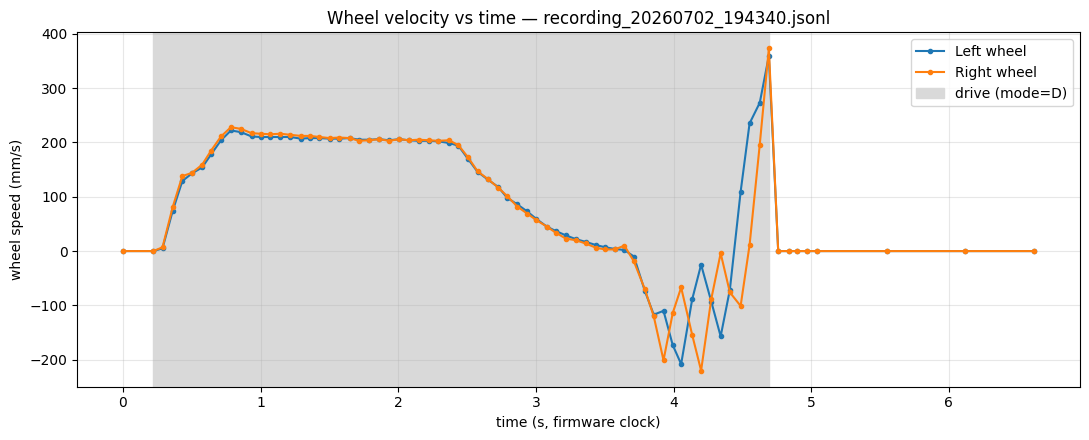

In [5]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(df["t_s"], df["vel_L_mms"], marker=".", lw=1.5, label="Left wheel")
ax.plot(df["t_s"], df["vel_R_mms"], marker=".", lw=1.5, label="Right wheel")

if not drive.empty:                                     # shade the mode=D drive phase
    ax.axvspan(drive["t_s"].iloc[0], drive["t_s"].iloc[-1],
               color="0.85", zorder=0, label="drive (mode=D)")

ax.set_xlabel("time (s, firmware clock)")
ax.set_ylabel("wheel speed (mm/s)")
ax.set_title(f"Wheel velocity vs time — {RECORDING_NAME}")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

## Velocity vs distance

Each wheel's speed is plotted against **that wheel's own** cumulative encoder distance.
For a straight drive the two curves nearly coincide (left/right travel almost the same
distance); divergence would indicate slip or a turn.

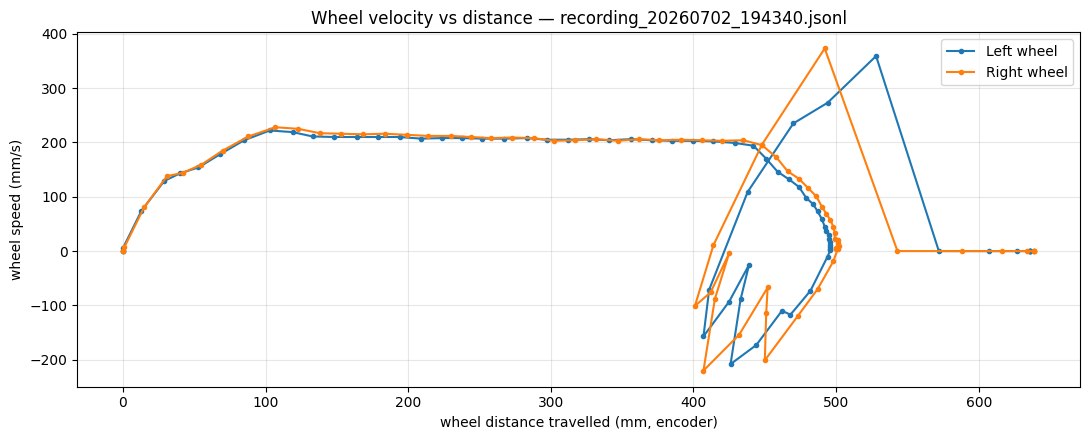

In [6]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(df["enc_L_mm"], df["vel_L_mms"], marker=".", lw=1.5, label="Left wheel")
ax.plot(df["enc_R_mm"], df["vel_R_mms"], marker=".", lw=1.5, label="Right wheel")

ax.set_xlabel("wheel distance travelled (mm, encoder)")
ax.set_ylabel("wheel speed (mm/s)")
ax.set_title(f"Wheel velocity vs distance — {RECORDING_NAME}")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

## Both views, side by side

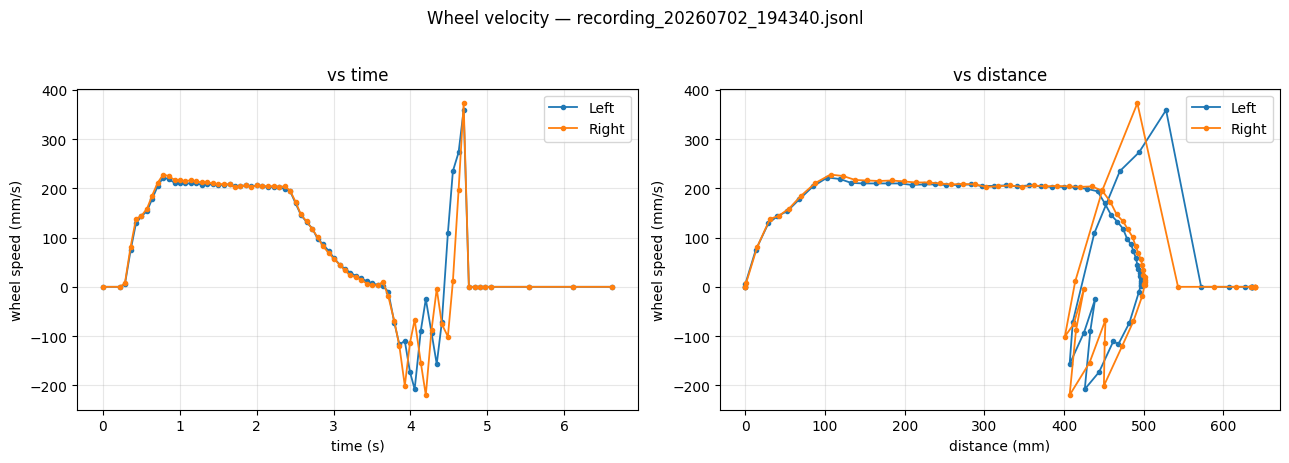

In [7]:
fig, (ax_t, ax_d) = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, xcol_L, xcol_R, xlabel, title in (
    (ax_t, "t_s", "t_s", "time (s)", "vs time"),
    (ax_d, "enc_L_mm", "enc_R_mm", "distance (mm)", "vs distance"),
):
    ax.plot(df[xcol_L], df["vel_L_mms"], marker=".", lw=1.3, label="Left")
    ax.plot(df[xcol_R], df["vel_R_mms"], marker=".", lw=1.3, label="Right")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("wheel speed (mm/s)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle(f"Wheel velocity — {RECORDING_NAME}", y=1.02)
fig.tight_layout()
plt.show()